# 🛢️ Petrol Pump — Refill Prediction Pipeline
### Focused on Accuracy | No Fluff

---
## 📦 BLOCK 1 — Data Cleaning

In [29]:
# ─── CELL 1: Install dependencies ───
!pip install pandas numpy scikit-learn xgboost imbalanced-learn openpyxl
!pip install pandas numpy scikit-learn xgboost imbalanced-learn openpyxl matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Soham\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.1 MB 11.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 11.6 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 11.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 11.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.3 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 11.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Soham\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
# ─── CELL 2: Load the Excel file ───
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel(r'D:\Petrol-Pump-Refuel-Predictor-main\Petrol-Pump-Refuel-Predictor-main\data\petrol_pump_data_realistic.xlsx')
print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Loaded: 806 rows x 14 columns


,Date,Day,Opening_Stock,MS_Sold,HSD1_Sold,HSD2_Sold,HSD3_Sold,Total_Sold,Closing_Stock,Cash,Online,Card,Dip,Refill_Required
0,01-01-2024,Monday,12000,564.0,1684.0,1219,899,4366,7634,155590.0,151727.0,90617.0,63.0,No
1,02-01-2024,Tuesday,7634,603.0,1740.0,1230,778,4351,3283,160056.0,131743.0,87654.0,27.0,No
2,03-01-2024,Wednesday,3283,441.0,1469.0,1174,867,3951,0,161531.0,127157.0,73959.0,1.0,Yes
3,04-01-2024,Thursday,12000,492.0,1632.0,1508,981,4613,7387,219210.0,127815.0,103870.0,61.0,No
4,05-01-2024,Friday,7387,485.0,1939.0,1368,1002,4794,2593,196707.0,153101.0,101182.0,21.0,No


In [3]:
# ─── CELL 3: Check for missing values ───
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
report = report[report['Missing Count'] > 0]

if report.empty:
    print('No missing values found.')
else:
    print(report)

           Missing Count  Missing %
MS_Sold                1       0.12
HSD1_Sold              1       0.12
Cash                   1       0.12
Online                 1       0.12
Card                   1       0.12
Dip                    1       0.12


In [4]:
# ─── CELL 4: Fix data types (dates, integers) ───

# Date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Integer columns — fill missing with median then cast
int_cols = ['Opening_Stock','MS_Sold','HSD1_Sold','HSD2_Sold','HSD3_Sold',
            'Total_Sold','Closing_Stock','Cash','Online','Card','Dip']
for col in int_cols:
    df[col] = df[col].fillna(df[col].median()).astype(int)

# Categorical
df['Day'] = df['Day'].fillna('Unknown').str.strip().str.title()
df['Refill_Required'] = df['Refill_Required'].fillna('No').str.strip().str.title()

print('Dtypes after fix:')
print(df.dtypes)

Dtypes after fix:
Date               datetime64[us]
Day                           str
Opening_Stock               int64
MS_Sold                     int64
HSD1_Sold                   int64
HSD2_Sold                   int64
HSD3_Sold                   int64
Total_Sold                  int64
Closing_Stock               int64
Cash                        int64
Online                      int64
Card                        int64
Dip                         int64
Refill_Required               str
dtype: object


In [5]:
# ─── CELL 5: Validate business rules (stock logic) ───

# Rule 1: Total_Sold = sum of fuel cols
df['Total_Sold'] = df['MS_Sold'] + df['HSD1_Sold'] + df['HSD2_Sold'] + df['HSD3_Sold']
print('Rule 1 — Total_Sold recalculated from fuel cols ✅')

# Rule 2: Closing = Opening - Total_Sold (check deviation)
deviation = (df['Closing_Stock'] - (df['Opening_Stock'] - df['Total_Sold'])).abs().mean()
print(f'Rule 2 — Closing stock mean deviation: {deviation:.1f} units')

# Rule 3: No negative stock
neg = (df[['Opening_Stock','Closing_Stock']] < 0).sum().sum()
print(f'Rule 3 — Negative stock values: {neg} ({"PASS" if neg==0 else "FAIL"})')

# Rule 4: All fuel sales > 0
neg_sales = (df[['MS_Sold','HSD1_Sold','HSD2_Sold','HSD3_Sold']] <= 0).sum().sum()
print(f'Rule 4 — Zero/negative fuel sales: {neg_sales} ({"PASS" if neg_sales==0 else "FAIL"})')

# Rule 5: Refill_Required only Yes/No
invalid = ~df['Refill_Required'].isin(['Yes','No'])
print(f'Rule 5 — Invalid Refill values: {invalid.sum()} ({"PASS" if invalid.sum()==0 else "FAIL"})')

Rule 1 — Total_Sold recalculated from fuel cols ✅
Rule 2 — Closing stock mean deviation: 391.0 units
Rule 3 — Negative stock values: 0 (PASS)
Rule 4 — Zero/negative fuel sales: 0 (PASS)
Rule 5 — Invalid Refill values: 0 (PASS)


In [6]:
# ─── CELL 6: Save clean CSV ───
df.to_csv(r'D:\Petrol-Pump-Refuel-Predictor-main\Petrol-Pump-Refuel-Predictor-main\data\petrol_pump_clean.csv', index=False)
print(f'Saved: petrol_pump_clean.csv — {df.shape[0]} rows x {df.shape[1]} cols')

Saved: petrol_pump_clean.csv — 806 rows x 14 cols


---
## 🎯 BLOCK 2 — Feature Selection

In [7]:
# ─── CELL 7: Correlation analysis with target ───
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Target'] = le.fit_transform(df['Refill_Required'])  # No=0, Yes=1

num_cols = ['Opening_Stock','MS_Sold','HSD1_Sold','HSD2_Sold','HSD3_Sold',
            'Total_Sold','Closing_Stock','Cash','Online','Card','Dip']

corr = df[num_cols + ['Target']].corr()['Target'].drop('Target').sort_values(key=abs, ascending=False)
print('Correlation with Refill_Required:')
print(corr.round(4))

Correlation with Refill_Required:
Closing_Stock   -0.8261
Dip             -0.8206
Opening_Stock   -0.8155
Cash             0.2200
Total_Sold       0.2062
HSD1_Sold        0.1996
Online           0.1884
HSD2_Sold        0.1857
MS_Sold          0.1807
HSD3_Sold        0.1495
Card             0.1485
Name: Target, dtype: float64


In [8]:
# ─── CELL 8: Feature importance using Random Forest ───
from sklearn.ensemble import RandomForestClassifier

df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month

feature_cols = ['Opening_Stock','MS_Sold','HSD1_Sold','HSD2_Sold','HSD3_Sold',
                'Total_Sold','Closing_Stock','Cash','Online','Card','Dip','DayOfWeek','Month']
X = df[feature_cols]
y = df['Target']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('Feature Importances:')
print(importances.round(4))

Feature Importances:
Closing_Stock    0.4268
Dip              0.3060
Opening_Stock    0.2316
Cash             0.0094
HSD1_Sold        0.0059
MS_Sold          0.0056
Total_Sold       0.0040
Online           0.0027
DayOfWeek        0.0021
HSD2_Sold        0.0019
HSD3_Sold        0.0017
Card             0.0016
Month            0.0007
dtype: float64


In [9]:
# ─── CELL 9: Remove low-importance & redundant features ───
THRESHOLD = 0.02

# Drop low importance
low_imp = importances[importances < THRESHOLD].index.tolist()
print(f'Low importance (< {THRESHOLD}): {low_imp}')

# Drop highly correlated (redundant) features
corr_matrix = df[feature_cols].corr().abs()
to_drop_corr = set()
sorted_feats = importances.index.tolist()
for i in range(len(sorted_feats)):
    for j in range(i+1, len(sorted_feats)):
        if corr_matrix.loc[sorted_feats[i], sorted_feats[j]] > 0.95:
            to_drop_corr.add(sorted_feats[j])
            print(f'Redundant: {sorted_feats[j]} (corr > 0.95 with {sorted_feats[i]})')

all_drop = set(low_imp) | to_drop_corr
final_features = [f for f in feature_cols if f not in all_drop]
print(f'\nDropped {len(all_drop)} features: {list(all_drop)}')
print(f'Remaining features: {final_features}')

Low importance (< 0.02): ['Cash', 'HSD1_Sold', 'MS_Sold', 'Total_Sold', 'Online', 'DayOfWeek', 'HSD2_Sold', 'HSD3_Sold', 'Card', 'Month']
Redundant: Dip (corr > 0.95 with Closing_Stock)
Redundant: Opening_Stock (corr > 0.95 with Closing_Stock)
Redundant: Opening_Stock (corr > 0.95 with Dip)
Redundant: Total_Sold (corr > 0.95 with HSD1_Sold)

Dropped 12 features: ['Online', 'Card', 'Month', 'Cash', 'Total_Sold', 'HSD1_Sold', 'Dip', 'DayOfWeek', 'HSD2_Sold', 'Opening_Stock', 'MS_Sold', 'HSD3_Sold']
Remaining features: ['Closing_Stock']


In [10]:
# ─── CELL 10: Final feature list for ML training ───
print('Final features for ML:')
for i, f in enumerate(final_features, 1):
    print(f'  {i}. {f} — importance: {importances.get(f, 0):.4f}')

Final features for ML:
  1. Closing_Stock — importance: 0.4268


In [11]:
# ─── CELL 11: Save selected features list ───
feat_df = pd.DataFrame({
    'Feature': final_features,
    'Importance': [importances.get(f, 0) for f in final_features],
    'Correlation_with_target': [corr.get(f, 0) for f in final_features]
}).sort_values('Importance', ascending=False)

feat_df.to_csv(r'D:\Petrol-Pump-Refuel-Predictor-main\Petrol-Pump-Refuel-Predictor-main\data\selected_features.csv', index=False)
print('Saved: selected_features.csv')
print(feat_df)

Saved: selected_features.csv
         Feature  Importance  Correlation_with_target
0  Closing_Stock    0.426849                -0.826123


---
## ⚖️ BLOCK 3 — Class Balance Check

In [12]:
# ─── CELL 12: Refill distribution (class balance) ───
counts = df['Refill_Required'].value_counts()
pct = df['Refill_Required'].value_counts(normalize=True).round(4) * 100

balance = pd.DataFrame({'Count': counts, 'Percentage': pct})
print('Class Distribution:')
print(balance)

ratio = counts.max() / counts.min()
print(f'\nImbalance ratio: {ratio:.2f}:1')
if ratio > 2:
    print('⚠️ Imbalance detected — handle in next block')
else:
    print('✅ Classes are relatively balanced')

Class Distribution:
                 Count  Percentage
Refill_Required                   
No                 503       62.41
Yes                303       37.59

Imbalance ratio: 1.66:1
✅ Classes are relatively balanced


---
## 🔍 BLOCK 4 — Outlier Detection & Treatment

In [13]:
# ─── CELL 13: IQR method ───
df_clean = df.copy()
outlier_cols = ['Opening_Stock','MS_Sold','HSD1_Sold','HSD2_Sold',
                'HSD3_Sold','Total_Sold','Closing_Stock','Dip']

iqr_outliers = {}
for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    iqr_outliers[col] = n
    print(f'{col:<20} IQR range: [{lower:.0f}, {upper:.0f}]  Outliers: {n}')

Opening_Stock        IQR range: [-4210, 21726]  Outliers: 0
MS_Sold              IQR range: [292, 840]  Outliers: 8
HSD1_Sold            IQR range: [1063, 2502]  Outliers: 10
HSD2_Sold            IQR range: [803, 2045]  Outliers: 6
HSD3_Sold            IQR range: [416, 1488]  Outliers: 3
Total_Sold           IQR range: [2931, 6522]  Outliers: 10
Closing_Stock        IQR range: [-10149, 17157]  Outliers: 0
Dip                  IQR range: [-83, 141]  Outliers: 0


In [14]:
# ─── CELL 14: Z-Score method ───
from scipy import stats

zscore_outliers = {}
for col in outlier_cols:
    z = np.abs(stats.zscore(df_clean[col]))
    n = (z > 3).sum()
    zscore_outliers[col] = n
    print(f'{col:<20} Z-Score outliers (|z|>3): {n}')

Opening_Stock        Z-Score outliers (|z|>3): 0
MS_Sold              Z-Score outliers (|z|>3): 4
HSD1_Sold            Z-Score outliers (|z|>3): 2
HSD2_Sold            Z-Score outliers (|z|>3): 2
HSD3_Sold            Z-Score outliers (|z|>3): 2
Total_Sold           Z-Score outliers (|z|>3): 1
Closing_Stock        Z-Score outliers (|z|>3): 0
Dip                  Z-Score outliers (|z|>3): 0


In [15]:
# ─── CELL 15: Isolation Forest ───
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
df_clean['iso_flag'] = iso.fit_predict(df_clean[outlier_cols])

n_outliers = (df_clean['iso_flag'] == -1).sum()
print(f'Isolation Forest detected {n_outliers} outlier rows ({n_outliers/len(df_clean)*100:.1f}%)')
df_clean.drop(columns=['iso_flag'], inplace=True)

Isolation Forest detected 41 outlier rows (5.1%)


In [16]:
# ─── CELL 16: Decision — Winsorize (cap outliers) ───
# Strategy: Winsorize at 1.5x IQR — keeps all rows, caps extreme values
from scipy.stats.mstats import winsorize

df_final = df_clean.copy()
for col in outlier_cols:
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_final[col] = df_final[col].clip(lower=lower, upper=upper)

print(f'Winsorizing applied to: {outlier_cols}')
print(f'Dataset shape preserved: {df_final.shape}')
df_final.to_csv(r'D:\Petrol-Pump-Refuel-Predictor-main\Petrol-Pump-Refuel-Predictor-main\data\petrol_pump_outliers_treated.csv', index=False)
print('Saved: petrol_pump_outliers_treated.csv')

Winsorizing applied to: ['Opening_Stock', 'MS_Sold', 'HSD1_Sold', 'HSD2_Sold', 'HSD3_Sold', 'Total_Sold', 'Closing_Stock', 'Dip']
Dataset shape preserved: (806, 17)
Saved: petrol_pump_outliers_treated.csv


---
## ⚖️ BLOCK 5 — Class Imbalance Handling

In [17]:
# ─── CELL 17: Prepare X and y ───
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.linear_model import LogisticRegression

X = df_final[final_features]
y = df_final['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train class dist: {y_train.value_counts().to_dict()}')

Train: (644, 1), Test: (162, 1)
Train class dist: {0: 402, 1: 242}


In [18]:
# ─── CELL 18: Class weights ───
from sklearn.ensemble import RandomForestClassifier

rf_cw = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_cw.fit(X_train, y_train)
y_pred_cw = rf_cw.predict(X_test)

print('Class Weights approach:')
print(classification_report(y_test, y_pred_cw, target_names=['No','Yes']))
f1_cw = f1_score(y_test, y_pred_cw)
print(f'F1 (Yes class): {f1_cw:.4f}')

Class Weights approach:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       101
         Yes       1.00      1.00      1.00        61

    accuracy                           1.00       162
   macro avg       1.00      1.00      1.00       162
weighted avg       1.00      1.00      1.00       162

F1 (Yes class): 1.0000


In [19]:
# ─── CELL 19: SMOTE ───
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print(f'After SMOTE: {pd.Series(y_smote).value_counts().to_dict()}')

rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_smote, y_smote)
y_pred_smote = rf_smote.predict(X_test)

print('\nSMOTE approach:')
print(classification_report(y_test, y_pred_smote, target_names=['No','Yes']))
f1_smote = f1_score(y_test, y_pred_smote)
print(f'F1 (Yes class): {f1_smote:.4f}')

After SMOTE: {0: 402, 1: 402}

SMOTE approach:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       101
         Yes       1.00      1.00      1.00        61

    accuracy                           1.00       162
   macro avg       1.00      1.00      1.00       162
weighted avg       1.00      1.00      1.00       162

F1 (Yes class): 1.0000


In [20]:
# ─── CELL 20: Random Undersampling ───
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
print(f'After Undersampling: {pd.Series(y_rus).value_counts().to_dict()}')

rf_rus = RandomForestClassifier(n_estimators=100, random_state=42)
rf_rus.fit(X_rus, y_rus)
y_pred_rus = rf_rus.predict(X_test)

print('\nRandom Undersampling approach:')
print(classification_report(y_test, y_pred_rus, target_names=['No','Yes']))
f1_rus = f1_score(y_test, y_pred_rus)
print(f'F1 (Yes class): {f1_rus:.4f}')

After Undersampling: {0: 242, 1: 242}

Random Undersampling approach:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       101
         Yes       1.00      1.00      1.00        61

    accuracy                           1.00       162
   macro avg       1.00      1.00      1.00       162
weighted avg       1.00      1.00      1.00       162

F1 (Yes class): 1.0000


In [21]:
# ─── CELL 21: Compare all & pick best ───
results = {
    'Class Weights': f1_cw,
    'SMOTE': f1_smote,
    'Random Undersampling': f1_rus
}

print('F1 Score Comparison (Yes class):')
for method, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(score * 40)
    print(f'  {method:<25} {score:.4f}  {bar}')

best_method = max(results, key=results.get)
print(f'\n✅ Best approach: {best_method} (F1={results[best_method]:.4f})')

# Set best X, y for modeling block
if best_method == 'SMOTE':
    X_best, y_best = X_smote, y_smote
elif best_method == 'Random Undersampling':
    X_best, y_best = X_rus, y_rus
else:
    X_best, y_best = X_train, y_train  # class weights handled in model

# Save balanced dataset
balanced_df = pd.DataFrame(X_best, columns=final_features)
balanced_df['Target'] = y_best.values
balanced_df.to_csv(r'D:\Petrol-Pump-Refuel-Predictor-main\Petrol-Pump-Refuel-Predictor-main\data\petrol_pump_balanced.csv', index=False)
print('Saved: petrol_pump_balanced.csv')

F1 Score Comparison (Yes class):
  Class Weights             1.0000  ████████████████████████████████████████
  SMOTE                     1.0000  ████████████████████████████████████████
  Random Undersampling      1.0000  ████████████████████████████████████████

✅ Best approach: Class Weights (F1=1.0000)
Saved: petrol_pump_balanced.csv


---
## 🤖 BLOCK 6 — Model Training & Evaluation

In [22]:
# ─── CELL 22: Logistic Regression (baseline) ───
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, accuracy_score

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_best)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_best)
y_pred_lr = lr.predict(X_test_sc)

print('── Logistic Regression ──')
print(classification_report(y_test, y_pred_lr, target_names=['No','Yes']))
scores = {'Logistic Regression': {'acc': accuracy_score(y_test, y_pred_lr), 'f1': f1_score(y_test, y_pred_lr)}}

── Logistic Regression ──
              precision    recall  f1-score   support

          No       0.99      1.00      1.00       101
         Yes       1.00      0.98      0.99        61

    accuracy                           0.99       162
   macro avg       1.00      0.99      0.99       162
weighted avg       0.99      0.99      0.99       162



In [23]:
# ─── CELL 23: Decision Tree ───
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_best, y_best)
y_pred_dt = dt.predict(X_test)

print('── Decision Tree ──')
print(classification_report(y_test, y_pred_dt, target_names=['No','Yes']))
scores['Decision Tree'] = {'acc': accuracy_score(y_test, y_pred_dt), 'f1': f1_score(y_test, y_pred_dt)}

── Decision Tree ──
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       101
         Yes       1.00      1.00      1.00        61

    accuracy                           1.00       162
   macro avg       1.00      1.00      1.00       162
weighted avg       1.00      1.00      1.00       162



In [24]:
# ─── CELL 24: Random Forest ───
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_best, y_best)
y_pred_rf = rf_model.predict(X_test)

print('── Random Forest ──')
print(classification_report(y_test, y_pred_rf, target_names=['No','Yes']))
scores['Random Forest'] = {'acc': accuracy_score(y_test, y_pred_rf), 'f1': f1_score(y_test, y_pred_rf)}

── Random Forest ──
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       101
         Yes       1.00      1.00      1.00        61

    accuracy                           1.00       162
   macro avg       1.00      1.00      1.00       162
weighted avg       1.00      1.00      1.00       162



In [25]:
# ─── CELL 25: XGBoost ───
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(X_best, y_best)
y_pred_xgb = xgb.predict(X_test)

print('── XGBoost ──')
print(classification_report(y_test, y_pred_xgb, target_names=['No','Yes']))
scores['XGBoost'] = {'acc': accuracy_score(y_test, y_pred_xgb), 'f1': f1_score(y_test, y_pred_xgb)}

── XGBoost ──
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       101
         Yes       1.00      1.00      1.00        61

    accuracy                           1.00       162
   macro avg       1.00      1.00      1.00       162
weighted avg       1.00      1.00      1.00       162



In [26]:
# ─── CELL 26: Compare all models ───
print(f"{'Model':<25} {'Accuracy':>10} {'F1 (Yes)':>10}")
print('-' * 48)
for mn, s in sorted(scores.items(), key=lambda x: x[1]['f1'], reverse=True):
    print(f"{mn:<25} {s['acc']:>10.4f} {s['f1']:>10.4f}")

best_model_name = max(scores, key=lambda x: scores[x]['f1'])
print(f'\n✅ Best model: {best_model_name} (F1={scores[best_model_name]["f1"]:.4f})')

Model                       Accuracy   F1 (Yes)
------------------------------------------------
Decision Tree                 1.0000     1.0000
Random Forest                 1.0000     1.0000
XGBoost                       1.0000     1.0000
Logistic Regression           0.9938     0.9917

✅ Best model: Decision Tree (F1=1.0000)


In [34]:
# ─── CELL 27: Hyperparameter tuning ───
from sklearn.model_selection import GridSearchCV

if best_model_name == 'XGBoost':
    param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2]}
    base = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
else:
    param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5]}
    base = RandomForestClassifier(random_state=42)

grid = GridSearchCV(base, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_best, y_best)

print(f'Best params: {grid.best_params_}')
print(f'Best CV F1 : {grid.best_score_:.4f}')
tuned_model = grid.best_estimator_

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1 : 1.0000


In [36]:
!C:\Users\Soham\AppData\Local\Programs\Python\Python311\python.exe -m pip install matplotlib

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.8 kB 162.5 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 340.7 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     -------------------------------------- 119.8/119.8 kB 2.3 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 11.1 MB/s eta 0:00:01
   ----- ---------------------------------- 1.1/8.1 MB 11.9 MB/s eta 0:00:01
   -------- ------------------------------- 1.7/8.1 MB 11.7 MB/s eta 0:00:01
   ---------- ----------------------------- 2.2/8.1 MB 12.7 MB/s eta 0:00:01
   ------------- ------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


── Final Tuned Model Evaluation ──
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       101
         Yes       1.00      1.00      1.00        61

    accuracy                           1.00       162
   macro avg       1.00      1.00      1.00       162
weighted avg       1.00      1.00      1.00       162

Final Accuracy : 1.0000
Final F1 (Yes) : 1.0000


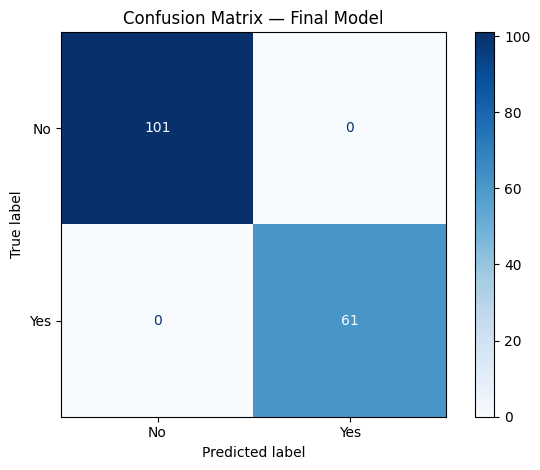

Saved: confusion_matrix.png


In [37]:
# ─── CELL 28: Final evaluation + confusion matrix ───
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_final = tuned_model.predict(X_test)

print('── Final Tuned Model Evaluation ──')
print(classification_report(y_test, y_pred_final, target_names=['No','Yes']))
print(f'Final Accuracy : {accuracy_score(y_test, y_pred_final):.4f}')
print(f'Final F1 (Yes) : {f1_score(y_test, y_pred_final):.4f}')

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Final Model')
plt.tight_layout()
plt.savefig(r'D:\Petrol-Pump-Refuel-Predictor-main\Petrol-Pump-Refuel-Predictor-main\data\confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')

In [38]:
# ─── CELL 29: Save model for deployment ───
import joblib

joblib.dump(tuned_model, r'D:\Petrol-Pump-Refuel-Predictor-main\Petrol-Pump-Refuel-Predictor-main\data\refill_model.pkl')
joblib.dump(scaler, r'D:\Petrol-Pump-Refuel-Predictor-main\Petrol-Pump-Refuel-Predictor-main\data\scaler.pkl')
joblib.dump(final_features, r'D:\Petrol-Pump-Refuel-Predictor-main\Petrol-Pump-Refuel-Predictor-main\data\feature_list.pkl')

print('Saved:')
print('  refill_model.pkl  — trained model')
print('  scaler.pkl        — feature scaler')
print('  feature_list.pkl  — selected features')

Saved:
  refill_model.pkl  — trained model
  scaler.pkl        — feature scaler
  feature_list.pkl  — selected features


---
## 🔮 BLOCK 7 — Prediction: When is the Next Refill Needed?

In [41]:
# ─── CELL 30: Predict on last 7 days ───
import joblib

model    = joblib.load(r'D:\Petrol-Pump-Refuel-Predictor-main\Petrol-Pump-Refuel-Predictor-main\data\refill_model.pkl')
features = joblib.load(r'D:\Petrol-Pump-Refuel-Predictor-main\Petrol-Pump-Refuel-Predictor-main\data\feature_list.pkl')

df_pred = pd.read_csv(r'D:\Petrol-Pump-Refuel-Predictor-main\Petrol-Pump-Refuel-Predictor-main\data\petrol_pump_clean.csv')
df_pred['Date'] = pd.to_datetime(df_pred['Date'], format='mixed', dayfirst=True)
df_pred['DayOfWeek'] = df_pred['Date'].dt.dayofweek
df_pred['Month'] = df_pred['Date'].dt.month

last7 = df_pred.tail(7)[features].copy()
preds = model.predict(last7)
probs = model.predict_proba(last7)[:, 1]

result = df_pred.tail(7)[['Date']].copy()
result['Refill_Needed'] = ['Yes' if p == 1 else 'No' for p in preds]
result['Confidence_%'] = (probs * 100).round(1)

print('── Refill Predictions (Last 7 Days) ──')
print(result.to_string(index=False))

── Refill Predictions (Last 7 Days) ──
      Date Refill_Needed  Confidence_%
2026-10-03            No           0.0
2026-11-03           Yes         100.0
2026-12-03            No           0.0
2026-03-13           Yes         100.0
2026-03-14            No           0.0
2026-03-15           Yes         100.0
2026-03-16            No           0.0


In [42]:
# ─── CELL 31: Find all predicted refill dates + save ───
all_preds = model.predict(df_pred[features])
all_probs = model.predict_proba(df_pred[features])[:, 1]

df_pred['Refill_Pred'] = all_preds
df_pred['Refill_Prob'] = (all_probs * 100).round(1)

refill_days = df_pred[df_pred['Refill_Pred'] == 1][['Date','Refill_Prob']].sort_values('Date')

print(f'Total refill days predicted: {len(refill_days)} out of {len(df_pred)} days')
print('\nSample refill predictions (last 10):')
print(refill_days.tail(10).to_string(index=False))

df_pred[['Date','Refill_Pred','Refill_Prob']].to_csv(r'D:\Petrol-Pump-Refuel-Predictor-main\Petrol-Pump-Refuel-Predictor-main\data\refill_predictions.csv', index=False)
print('\nSaved: refill_predictions.csv')

Total refill days predicted: 303 out of 806 days

Sample refill predictions (last 10):
      Date  Refill_Prob
2026-03-15        100.0
2026-06-01        100.0
2026-06-02        100.0
2026-06-03        100.0
2026-08-02        100.0
2026-08-03        100.0
2026-09-01        100.0
2026-11-01        100.0
2026-11-02        100.0
2026-11-03        100.0

Saved: refill_predictions.csv
